# ClarityNet: DCCRN Training

This notebook:
1. Loads the train/val/test splits from notebook 02
2. Defines DCCRN architecture
3. Implements the training loop with validation on seen and unseen noise
4. Tracks the generalization gap during training
5. Saves checkpoints and training history

In [1]:
# Imports
import os
import sys
import json
import random
import numpy as np
# %matplotlib inline

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# For module imports
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import ComplexWaveformDataset
from src.data.manifest import load_manifest

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Imports successful!")

✓ Dataset classes defined
Imports successful!


In [2]:
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


## Configuration

In [3]:
# Training hyperparameters
BATCH_SIZE = 8         # Adjust based on your GPU memory
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
SAVE_EVERY = 5  # Save checkpoint every N epochs

# Paths
PROJECT_ROOT = Path("..").resolve() 
MANIFEST_PATH = PROJECT_ROOT / "data" / "MANIFEST.json"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "dccrn_si_snr_eval"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results" / "dccrn_si_snr_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print(f"  Results dir: {RESULTS_DIR}")

Configuration:
  Device: cuda
  Batch size: 8
  Learning rate: 0.0001
  Epochs: 50
  Checkpoint dir: /home/paul/Desktop/projects/clarity-net/checkpoints/dccrn_si_snr_eval
  Results dir: /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval


## Create Datasets

In [4]:
print("Creating datasets...\n")

splits = load_manifest(MANIFEST_PATH)

train_dataset = ComplexWaveformDataset(
    clean_files=splits['train'], 
    noise_files=splits['noise_seen'], 
    mode='train',
    augmentation_factor=5,
    base_seed=42,
    epoch=0
)

val_seen_dataset = ComplexWaveformDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_seen'],
    mode='val',
    eval_pairs_per_clean=3,
    base_seed=42
)

val_unseen_dataset = ComplexWaveformDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_unseen'],
    mode='val',
    eval_pairs_per_clean=3,
    base_seed=43
)

test_seen_dataset = ComplexWaveformDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_seen'],
    mode='test',
    eval_pairs_per_clean=3,
    base_seed=44
)

test_unseen_dataset = ComplexWaveformDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_unseen'],
    mode='test',
    eval_pairs_per_clean=3,
    base_seed=45
)

print("\n" + "="*60)
print(f"Training:          {len(train_dataset)} pairs")
print(f"Validation (seen): {len(val_seen_dataset)} pairs")
print(f"Validation (uns.): {len(val_unseen_dataset)} pairs")
print(f"Test (seen):       {len(test_seen_dataset)} pairs")
print(f"Test (uns.):       {len(test_unseen_dataset)} pairs")
print("="*60)

Creating datasets...

[TRAIN] Loading 160 clean files...
[TRAIN] Loading 38 noise files...
[TRAIN] Base clean segments: 285, noise segments: 76, augmentation_factor: 5
[VAL] Loading 20 clean files...
[VAL] Loading 38 noise files...
[VAL] Base clean segments: 36, noise segments: 76, augmentation_factor: 1
[VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[VAL] Total fixed pairs: 108
[VAL] Loading 20 clean files...
[VAL] Loading 22 noise files...
[VAL] Base clean segments: 36, noise segments: 44, augmentation_factor: 1
[VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[VAL] Total fixed pairs: 108
[TEST] Loading 20 clean files...
[TEST] Loading 38 noise files...
[TEST] Base clean segments: 33, noise segments: 76, augmentation_factor: 1
[TEST] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[TEST] Total fixed pairs: 99
[TEST] Loading 20 clean files...
[TEST] Loading 22 noise files...
[TEST] Base clean segments: 33, noise segments: 

## Create DataLoaders

In [5]:
# Ensure shuffling is deterministic for reproducibility
train_gen = torch.Generator().manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_gen)
val_seen_loader = DataLoader(val_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_unseen_loader = DataLoader(val_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val (seen) batches: {len(val_seen_loader)}")
print(f"  Val (unseen) batches: {len(val_unseen_loader)}")
print(f"  Test (seen) batches: {len(test_seen_loader)}")
print(f"  Test (unseen) batches: {len(test_unseen_loader)}")

DataLoaders created:
  Train batches: 179
  Val (seen) batches: 14
  Val (unseen) batches: 14
  Test (seen) batches: 13
  Test (unseen) batches: 13


## Define DCCRN model

In [6]:
from src.models.dccrn import DCCRN, count_parameters
# from src.models.model_utils import count_parameters

# Create model
model = DCCRN(lstm_hidden=128, lstm_layers=2).to(DEVICE)

print(f"Model created with {count_parameters(model):,} parameters")
# print(f"Model created with {model.count_parameters():,} parameters")
    
print("✓ Model ready")

Model created with 3,916,043 parameters
✓ Model ready


## Training Setup

In [7]:
from src.training.losses import complex_l1_loss

# Loss and optimizer
criterion = complex_l1_loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Loss function: L1 Loss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: L1 Loss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau


Val seen SNR:
  count: 108
  mean:  10.21 dB
  std:   5.81 dB
  min:   0.14 dB
  q25:   4.58 dB
  q50:   10.75 dB
  q75:   15.21 dB
  max:   19.95 dB

Val unseen SNR:
  count: 108
  mean:  10.22 dB
  std:   5.55 dB
  min:   0.20 dB
  q25:   5.15 dB
  q50:   10.40 dB
  q75:   14.47 dB
  max:   19.78 dB



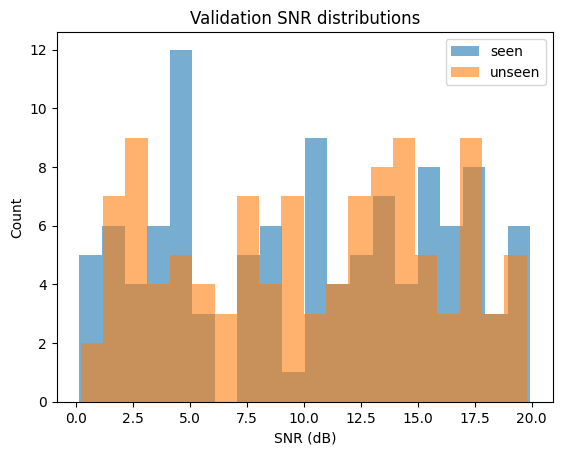

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def collect_snrs(loader):
    snrs = []
    for batch in loader:
        batch_snrs = batch["snr"]

        # handle tensor or plain list
        if hasattr(batch_snrs, "cpu"):
            snrs.extend(batch_snrs.cpu().numpy().tolist())
        else:
            snrs.extend(list(batch_snrs))

    return np.array(snrs, dtype=float)

def summarize_snrs(name, snrs):
    print(f"{name}:")
    print(f"  count: {len(snrs)}")
    print(f"  mean:  {snrs.mean():.2f} dB")
    print(f"  std:   {snrs.std():.2f} dB")
    print(f"  min:   {snrs.min():.2f} dB")
    print(f"  q25:   {np.percentile(snrs, 25):.2f} dB")
    print(f"  q50:   {np.percentile(snrs, 50):.2f} dB")
    print(f"  q75:   {np.percentile(snrs, 75):.2f} dB")
    print(f"  max:   {snrs.max():.2f} dB")
    print()

seen_snrs = collect_snrs(val_seen_loader)
unseen_snrs = collect_snrs(val_unseen_loader)

summarize_snrs("Val seen SNR", seen_snrs)
summarize_snrs("Val unseen SNR", unseen_snrs)

plt.hist(seen_snrs, bins=20, alpha=0.6, label="seen")
plt.hist(unseen_snrs, bins=20, alpha=0.6, label="unseen")
plt.xlabel("SNR (dB)")
plt.ylabel("Count")
plt.title("Validation SNR distributions")
plt.legend()
plt.show()

## Run Training

In [9]:
%%time

"""
Updated training loop with PESQ/STOI metrics.

Replace your current training loop with this version.
"""

from src.models.model_utils import save_checkpoint, train_epoch
from src.evaluation.metrics import validate_with_metrics

# Training history - EXPANDED to include PESQ/STOI
history = {
    'train_loss': [],
    'val_seen_loss': [],
    'val_seen_pesq': [],
    'val_seen_stoi': [],
    'val_seen_si_snr': [],
    'val_unseen_loss': [],
    'val_unseen_pesq': [],
    'val_unseen_stoi': [],
    'val_unseen_si_snr': [],
    'generalization_gap_loss': [],
    'generalization_gap_pesq': [],
    'generalization_gap_stoi': [],
    'generalization_gap_si_snr': [],
    'learning_rate': []
}

best_val_loss = float('inf')
epochs_without_improvement = 0

print("="*70)
print("Starting Training with PESQ/STOI/SI-SNR Tracking")
print("="*70)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Update dataset epoch for deterministic augmentation
    train_dataset.epoch = epoch
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device=DEVICE)
    
    # Validate with metrics (PESQ/STOI computed on subset)
    val_seen_metrics = validate_with_metrics(
        model=model, 
        loader=val_seen_loader, 
        criterion=criterion, 
        device=DEVICE,
        max_pesq_samples=100  # Compute PESQ/STOI on 100 examples
    )
    
    val_unseen_metrics = validate_with_metrics(
        model=model,
        loader=val_unseen_loader,
        criterion=criterion,
        device=DEVICE,
        max_pesq_samples=100
    )
    
    # Update scheduler
    scheduler.step(val_seen_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Compute gaps
    gap_loss = val_unseen_metrics['loss'] - val_seen_metrics['loss']
    gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']  # Note: Higher PESQ is better
    gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']  # Note: Higher STOI is better
    gap_si_snr = val_seen_metrics['si_snr'] - val_unseen_metrics['si_snr']  # Note: Higher SI-SNR is better
    
    # Log everything
    history['train_loss'].append(train_loss)
    history['val_seen_loss'].append(val_seen_metrics['loss'])
    history['val_seen_pesq'].append(val_seen_metrics['pesq'])
    history['val_seen_stoi'].append(val_seen_metrics['stoi'])
    history['val_seen_si_snr'].append(val_seen_metrics['si_snr'])
    history['val_unseen_loss'].append(val_unseen_metrics['loss'])
    history['val_unseen_pesq'].append(val_unseen_metrics['pesq'])
    history['val_unseen_stoi'].append(val_unseen_metrics['stoi'])
    history['val_unseen_si_snr'].append(val_unseen_metrics['si_snr'])
    history['generalization_gap_loss'].append(gap_loss)
    history['generalization_gap_pesq'].append(gap_pesq)
    history['generalization_gap_stoi'].append(gap_stoi)
    history['generalization_gap_si_snr'].append(gap_si_snr)
    history['learning_rate'].append(current_lr)
    
    # Pretty print results
    print(f"\nResults:")
    print(f"  Train Loss:         {train_loss:.6f}")
    print(f"  Val (seen)   - Loss: {val_seen_metrics['loss']:.6f}  "
          f"PESQ: {val_seen_metrics['pesq']:.3f}  "
          f"STOI: {val_seen_metrics['stoi']:.3f}  "
          f"SI-SNR: {val_seen_metrics['si_snr']:.3f}")
    print(f"  Val (unseen) - Loss: {val_unseen_metrics['loss']:.6f}  "
          f"PESQ: {val_unseen_metrics['pesq']:.3f}  "
          f"STOI: {val_unseen_metrics['stoi']:.3f}  "
          f"SI-SNR: {val_unseen_metrics['si_snr']:.3f}")
    print(f"  Gen. Gap     - Loss: {gap_loss:+.6f}  "
          f"PESQ: {gap_pesq:+.3f}  "
          f"STOI: {gap_stoi:+.3f}  "
          f"SI-SNR: {gap_si_snr:+.3f}")
    print(f"  Learning Rate:      {current_lr:.2e}")
    
    # Checkpointing (still based on MSE loss)
    if val_seen_metrics['loss'] < best_val_loss:
        best_val_loss = val_seen_metrics['loss']
        epochs_without_improvement = 0
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=True)
        print("  ✓ New best model!")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")
    
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=False)
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
        break

print("\n" + "="*70)
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*70)

# Save final history
with open(RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {RESULTS_DIR / 'training_history.json'}")

# Print final summary
print("\nFinal Metrics Summary:")
print(f"  Seen   - PESQ: {history['val_seen_pesq'][-1]:.3f}, STOI: {history['val_seen_stoi'][-1]:.3f}, SI-SNR: {history['val_seen_si_snr'][-1]:.3f}")
print(f"  Unseen - PESQ: {history['val_unseen_pesq'][-1]:.3f}, STOI: {history['val_unseen_stoi'][-1]:.3f}, SI-SNR: {history['val_unseen_si_snr'][-1]:.3f}")
print(f"  Gap    - PESQ: {history['generalization_gap_pesq'][-1]:+.3f}, STOI: {history['generalization_gap_stoi'][-1]:+.3f}, SI-SNR: {history['generalization_gap_si_snr'][-1]:+.3f}")

Starting Training with PESQ/STOI/SI-SNR Tracking

Epoch 1/50
----------------------------------------------------------------------


Training:   0%|          | 0/179 [00:00<?, ?it/s]

[DCCRN] Initializing LSTM with input_size=4608


Training: 100%|██████████| 179/179 [03:58<00:00,  1.33s/it, loss=0.014760]



Results:
  Train Loss:         0.043970
  Val (seen)   - Loss: 0.058363  PESQ: 2.389  STOI: 0.917  SI-SNR: 12.157
  Val (unseen) - Loss: 0.052851  PESQ: 2.160  STOI: 0.906  SI-SNR: 10.618
  Gen. Gap     - Loss: -0.005511  PESQ: +0.229  STOI: +0.011  SI-SNR: +1.539
  Learning Rate:      1.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/dccrn_si_snr_eval/best_model.pth
  ✓ New best model!

Epoch 2/50
----------------------------------------------------------------------


...


Results:
  Train Loss:         0.026099
  Val (seen)   - Loss: 0.039158  PESQ: 2.658  STOI: 0.930  SI-SNR: 17.426
  Val (unseen) - Loss: 0.040090  PESQ: 2.335  STOI: 0.916  SI-SNR: 12.726
  Gen. Gap     - Loss: +0.000932  PESQ: +0.322  STOI: +0.013  SI-SNR: +4.700
  Learning Rate:      1.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/dccrn_si_snr_eval/best_model.pth
  ✓ New best model!

Epoch 49/50
----------------------------------------------------------------------


Training: 100%|██████████| 179/179 [03:24<00:00,  1.14s/it, loss=0.006607]



Results:
  Train Loss:         0.027391
  Val (seen)   - Loss: 0.039246  PESQ: 2.656  STOI: 0.929  SI-SNR: 17.213
  Val (unseen) - Loss: 0.038975  PESQ: 2.349  STOI: 0.917  SI-SNR: 12.960
  Gen. Gap     - Loss: -0.000271  PESQ: +0.307  STOI: +0.012  SI-SNR: +4.252
  Learning Rate:      1.00e-04
  No improvement for 1 epoch(s)

Epoch 50/50
----------------------------------------------------------------------


Training: 100%|██████████| 179/179 [03:24<00:00,  1.14s/it, loss=0.002961]



Results:
  Train Loss:         0.027849
  Val (seen)   - Loss: 0.039231  PESQ: 2.656  STOI: 0.929  SI-SNR: 17.483
  Val (unseen) - Loss: 0.039178  PESQ: 2.355  STOI: 0.918  SI-SNR: 12.970
  Gen. Gap     - Loss: -0.000053  PESQ: +0.301  STOI: +0.011  SI-SNR: +4.513
  Learning Rate:      1.00e-04
  No improvement for 2 epoch(s)
  ✓ Saved checkpoint to /home/paul/Desktop/projects/clarity-net/checkpoints/dccrn_si_snr_eval/checkpoint_epoch_50.pth

Training Complete!
Best validation loss: 0.039158
Training history saved to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/training_history.json

Final Metrics Summary:
  Seen   - PESQ: 2.656, STOI: 0.929, SI-SNR: 17.483
  Unseen - PESQ: 2.355, STOI: 0.918, SI-SNR: 12.970
  Gap    - PESQ: +0.301, STOI: +0.011, SI-SNR: +4.513
CPU times: user 2h 47min 15s, sys: 1h 48min 38s, total: 4h 35min 53s
Wall time: 3h 23min 24s


In [10]:
print(f"Model trained with {count_parameters(model):,} parameters")

Model trained with 7,068,427 parameters


## Visualize Training

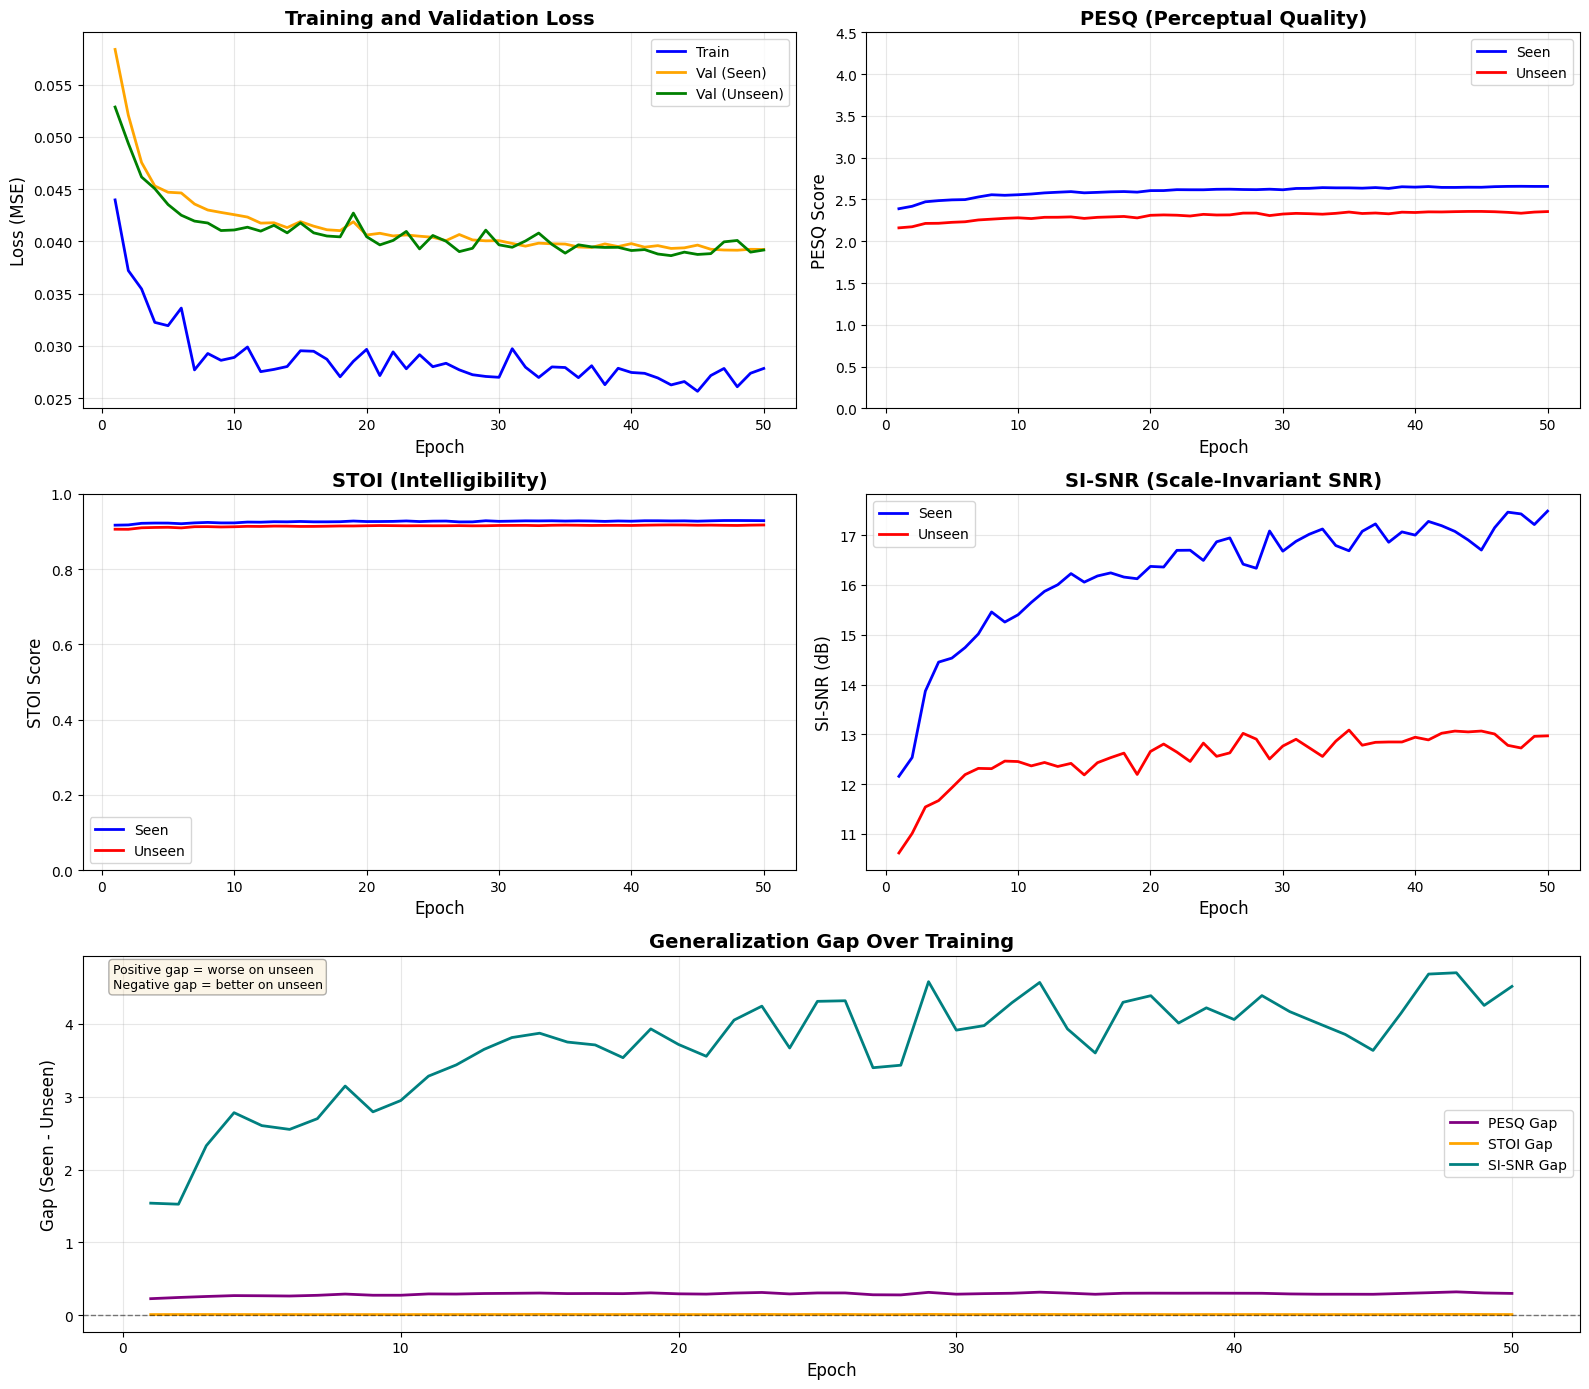

✓ Saved training curves to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/training_curves_with_metrics.png

Training Summary

Best epoch: 48
  Loss (seen):   0.039158
  Loss (unseen): 0.040090
  PESQ (seen):   2.658
  PESQ (unseen): 2.335
  STOI (seen):   0.930
  STOI (unseen): 0.916
  SI-SNR (seen): 17.426 dB
  SI-SNR (unseen): 12.726 dB

Final epoch: 50
  Loss (seen):   0.039231
  Loss (unseen): 0.039178
  PESQ (seen):   2.656
  PESQ (unseen): 2.355
  STOI (seen):   0.929
  STOI (unseen): 0.918
  SI-SNR (seen): 17.483 dB
  SI-SNR (unseen): 12.970 dB

Generalization Gaps (at best epoch):
  PESQ: +0.322
  STOI: +0.013
  SI-SNR: +4.700 dB

Generalization Gaps (at final epoch):
  PESQ: +0.301
  STOI: +0.011
  SI-SNR: +4.513 dB


In [11]:
from src.evaluation.visualize import plot_loss_curves

plot_loss_curves(history, RESULTS_DIR)

## Run Evaluation

In [12]:
from src.evaluation.evaluate import evaluate_model

# Dummy input matching training shape
dummy = torch.zeros(1, 2, 257, 251, device=DEVICE)

with torch.no_grad():
    _ = model(dummy)   # initializes self.lstm and self.lstm_fc

checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

results_seen, results_unseen = evaluate_model(model, test_seen_loader, test_unseen_loader, RESULTS_DIR, device=DEVICE)

Evaluating Model

Evaluating on SEEN noise types...


Test (Seen): 100%|██████████| 13/13 [00:11<00:00,  1.10it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 13/13 [00:11<00:00,  1.10it/s]


Results Summary

SEEN Noise Types:
  MSE:  0.009406
  PESQ: 2.669 ± 0.950
  STOI: 0.937 ± 0.080
  SI-SNR: 17.169 ± 11.522

UNSEEN Noise Types:
  MSE:  0.014996
  PESQ: 2.274 ± 0.792
  STOI: 0.911 ± 0.088
  SI-SNR: 12.307 ± 6.077

Generalization Gap:
  PESQ: 0.396
  STOI: 0.026
  SI-SNR: 4.862

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/evaluation_results.json


## Visualize Audio Samples

Sample 1 - SNR: 10.4 dB
  PESQ: 1.996
  STOI: 0.949



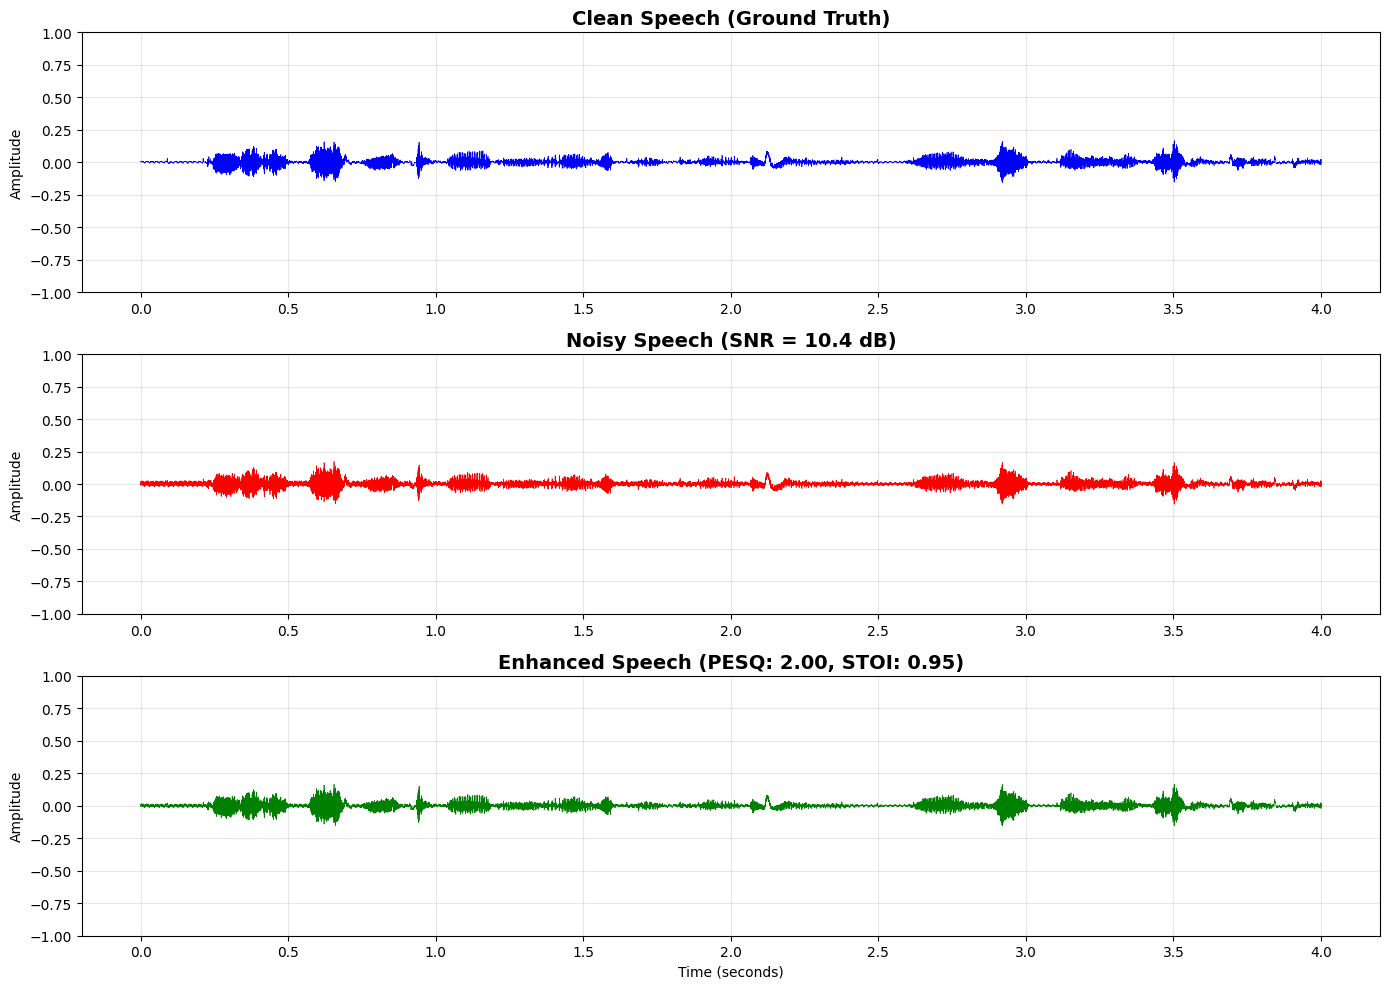

Waveform saved to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/waveform_comparison_sample_0.png


In [13]:
from src.evaluation.visualize import visualize_audio_samples

visualize_audio_samples(results_seen, RESULTS_DIR)

## Overlay Plots

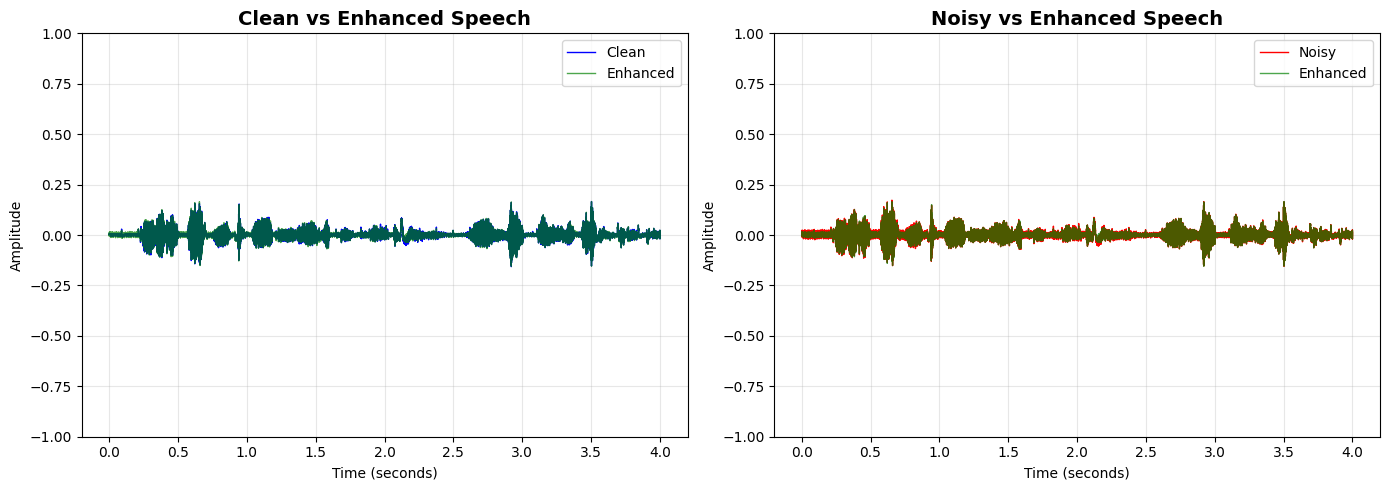

Overlay plots saved to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/overlay_comparison.png


In [14]:
from src.evaluation.visualize import visualize_audio_overlay

visualize_audio_overlay(results_seen, RESULTS_DIR)

## Audio Playback

In [15]:
from src.evaluation.visualize import playback_audio

playback_audio(results_seen)

Audio Data Inspection:
Sample rate: 16000 Hz
Clean audio shape: (64000,)
Clean audio dtype: float32
Clean audio range: [-0.156769, 0.166138]
Clean audio RMS: 0.019491
Clean audio duration: 4.00 seconds

Noisy audio shape: (64000,)
Noisy audio range: [-0.155119, 0.172804]
Noisy audio RMS: 0.020349

Enhanced audio shape: (64000,)
Enhanced audio range: [-0.154658, 0.165770]
Enhanced audio RMS: 0.019446

Clean Speech:



Noisy Speech (SNR = 10.4 dB):



Enhanced Speech (PESQ = 2.00, STOI = 0.95):


## Plot Metric Distributions

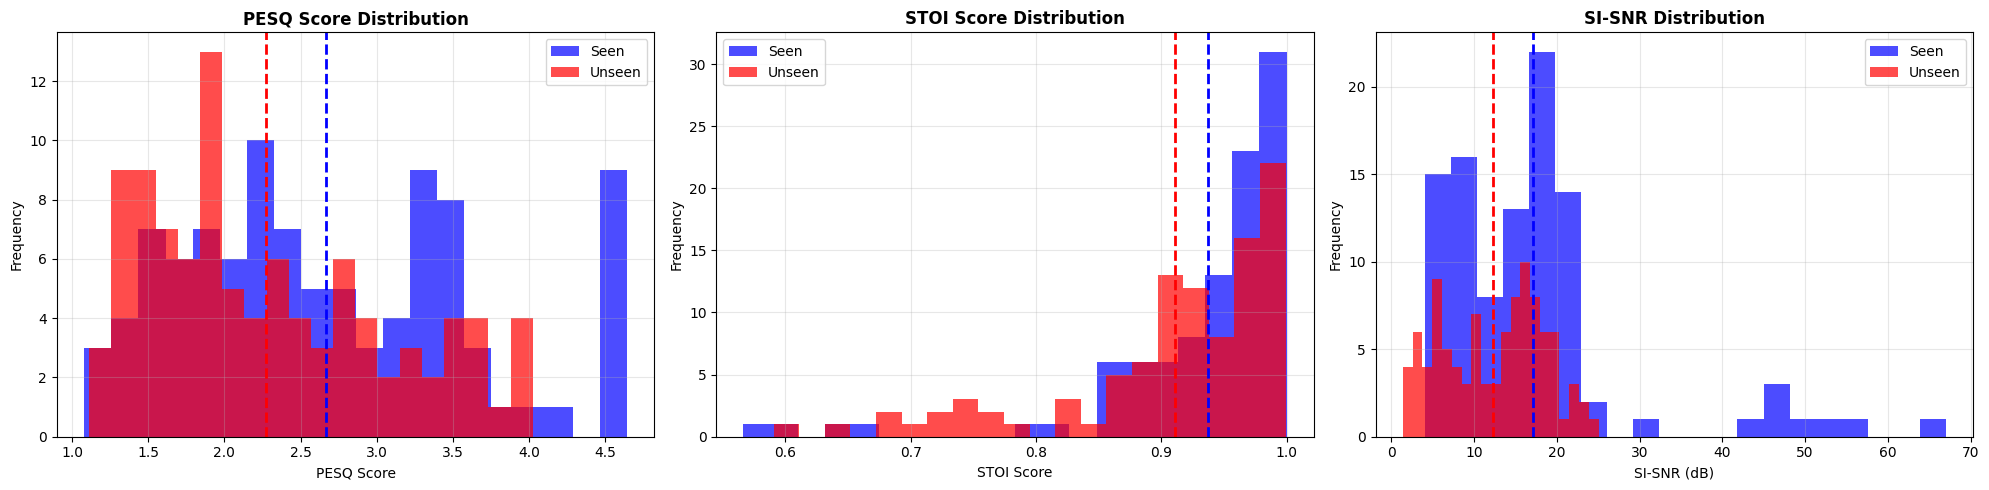

Metric distributions saved to /home/paul/Desktop/projects/clarity-net/results/dccrn_si_snr_eval/metric_distributions.png


In [16]:
from src.evaluation.visualize import plot_metric_distributions

plot_metric_distributions(results_seen, results_unseen, RESULTS_DIR)